In [24]:
from sklearn.metrics import roc_auc_score, accuracy_score
import torch, time, numpy as np
import os, sys
import matplotlib.pyplot as plt

helpers_path = os.path.join('/ether/aegis/Research_HEP/NRAD/oldver/NRAD/non-resonant-AD/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier
from SimpleMAF import SimpleMAF

In [17]:
# Load Test Dataset
seed = 2
n_context = 2
data_path = f"SemiVisJets/data/data_seed{seed}"
mc_path = "SemiVisJets/data"
model_path = f"SemiVisJets/models"


mc_events = np.load(f"{mc_path}/mc_events_chunk{1:02d}.npz", allow_pickle=True)
data_events = np.load(f"{data_path}/data_events_chunk{6:02d}.npz", allow_pickle=True)

mc_events_cr = mc_events["mc_events_cr"]
data_events_cr = data_events["data_events_cr"]
print(mc_events_cr.shape, data_events_cr.shape)

(9953032, 7) (9983635, 7)


In [7]:
CUDA = torch.cuda.is_available()
device = torch.device("cuda" if CUDA else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Load trained models
models = {}
for i in range(1, 6):
    models[f"context_weight_MC{seed:02d}_Data{i:02d}"] = torch.load(f"{model_path}/context_weight_MC{seed:02d}_Data{i:02d}.pt", map_location=device,  weights_only=False) 
    models[f"generate_MC{seed:02d}_Data{i:02d}"] = torch.load(f"{model_path}/generate_MC{seed:02d}_Data{i:02d}.pt", map_location=device,  weights_only=False)
    models[f"reweight_MC{seed:02d}_Data{i:02d}"] = torch.load(f"{model_path}/reweight_MC{seed:02d}_Data{i:02d}.pt", map_location=device,  weights_only=False)

In [20]:
# Evaluate Context Weights
X_mc   = mc_events_cr[:, :2]
X_data = data_events_cr[:, :2]

print(X_mc.shape, X_data.shape)

(9953032, 2) (9983635, 2)


MC f(x): mean=0.4184, std=0.2146
Data f(x): mean=0.5822, std=0.1551
Normalized weights: mean=1.000, std=0.829, max=52.480


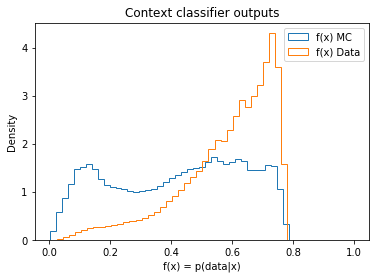

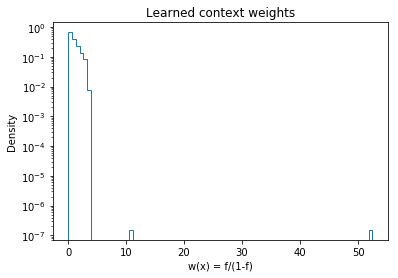

MC f(x): mean=0.4237, std=0.2122
Data f(x): mean=0.5869, std=0.1559
Normalized weights: mean=1.000, std=0.837, max=5.150


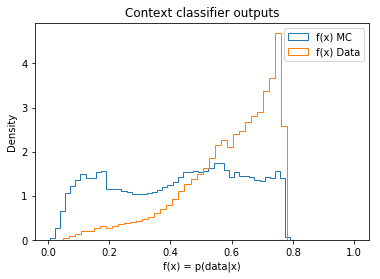

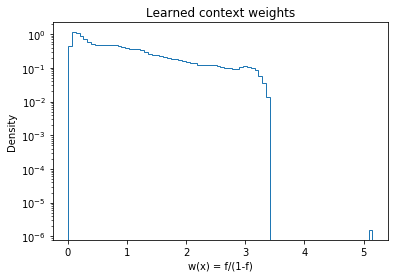

MC f(x): mean=0.4195, std=0.2093
Data f(x): mean=0.5802, std=0.1531
Normalized weights: mean=1.000, std=338.926, max=1069257.625


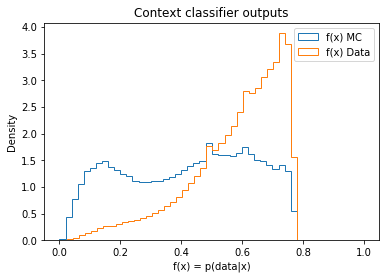

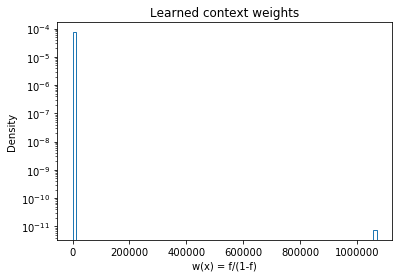

MC f(x): mean=0.4226, std=0.2170
Data f(x): mean=0.5893, std=0.1590
Normalized weights: mean=1.000, std=1.154, max=2444.262


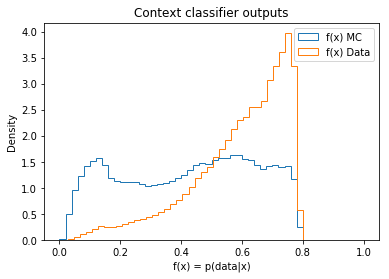

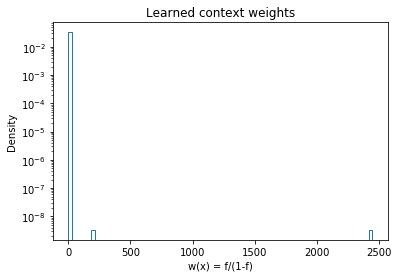

MC f(x): mean=0.4188, std=0.2112
Data f(x): mean=0.5809, std=0.1557
Normalized weights: mean=1.000, std=0.834, max=12.059


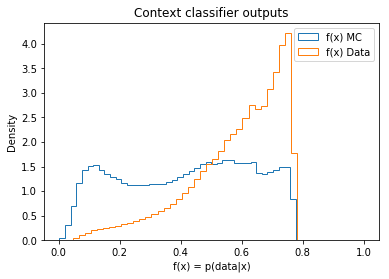

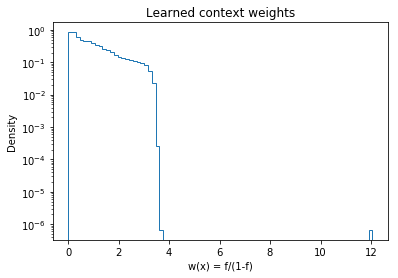

In [ ]:
for i in range(1, 6):
    model_key = f"context_weight_MC{seed:02d}_Data{i:02d}"
    context_model = models[model_key]
    context_model.model.eval()

    # The Classifier.evaluation() method from your code already handles torch conversion
    f_mc   = context_model.evaluation(X_mc)
    f_data = context_model.evaluation(X_data)

    print(f"MC f(x): mean={f_mc.mean():.4f}, std={f_mc.std():.4f}")
    print(f"Data f(x): mean={f_data.mean():.4f}, std={f_data.std():.4f}")

    # ------------------------------------------------------------
    # 4. Compute weights  w(x) = f(x) / (1 - f(x))
    # ------------------------------------------------------------
    eps = 1e-9  # to avoid division by zero
    w_mc = f_mc / (1 - f_mc + eps)

    # Normalize the weights so total weight = number of MC events
    w_mc_norm = w_mc * (len(w_mc) / np.sum(w_mc))

    print(f"Normalized weights: mean={w_mc_norm.mean():.3f}, std={w_mc_norm.std():.3f}, max={w_mc_norm.max():.3f}")

    plt.hist(f_mc, bins=50, density=True, histtype='step', label='f(x) MC')
    plt.hist(f_data, bins=50, density=True, histtype='step', label='f(x) Data')
    plt.xlabel('f(x) = p(data|x)')
    plt.ylabel('Density')
    plt.legend()
    plt.title('Context classifier outputs')
    plt.show()

    plt.hist(w_mc_norm, bins=80, density=True, histtype='step')
    plt.yscale('log')
    plt.xlabel('w(x) = f/(1-f)')
    plt.ylabel('Density')
    plt.title('Learned context weights')
    plt.show()